In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

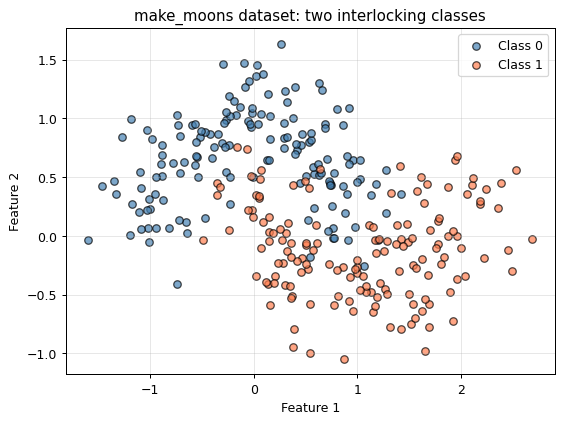

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Logistic regression accuracy (test): 0.883


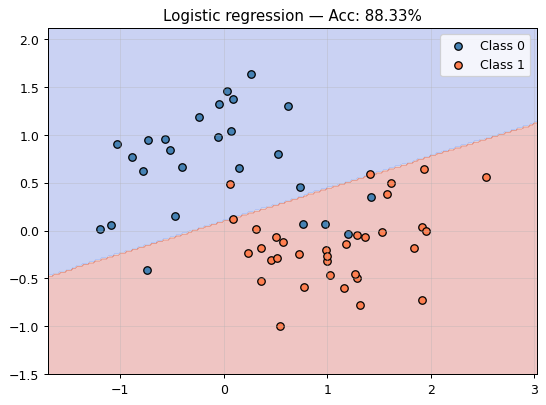

In [3]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

print(f'Logistic regression accuracy (test): {acc_logreg:.3f}')
plot_decision_boundary(logreg, X_test, y_test, f'Logistic regression — Acc: {acc_logreg:.2%}')

In [8]:

def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('clf',    LogisticRegressionCV(Cs=20, cv=5, max_iter=5000)),
])
logreg = GridSearchCV(logreg, {'poly__degree': [1, 2, 3, 4, 5]}, cv=5, n_jobs=-1)
logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

print(f'Logistic regression accuracy (test): {acc_logreg:.3f}')
plot_decision_boundary(logreg, X_test, y_test, f'Logistic regression — Acc: {acc_logreg:.2%}')

NameError: name 'Pipeline' is not defined

## 3. Attempt 2: decision tree

A tree works in a radically different way. Instead of learning weights, it **learns questions**:

```
Is Feature 2 > 0.3?
├── Yes → Is Feature 1 > 0.5?
│   ├── Yes → Class 1
│   └── No  → Class 0
└── No  → Is Feature 1 > -0.2?
    ├── Yes → Class 0
    └── No  → Class 1
```

Each question splits the space with a **line parallel to one axis**. The combination of several questions produces a staircase-shaped boundary that can approximate any shape.

Decision tree accuracy (max_depth=5, test): 0.900
Improvement over logistic regression: +1.7 points


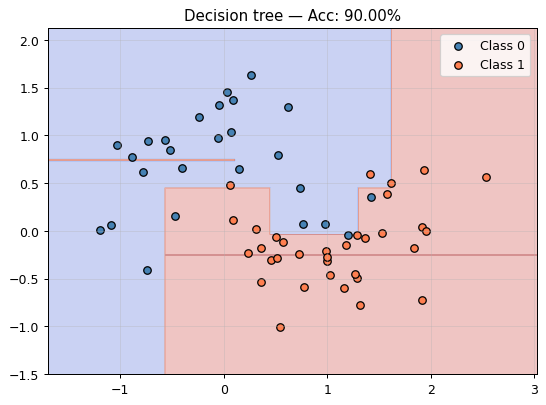

In [5]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

print(f'Decision tree accuracy (max_depth=5, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points')

plot_decision_boundary(tree, X_test, y_test, f'Decision tree — Acc: {acc_tree:.2%}')

Decision tree accuracy (optimized, test): 0.850
Improvement over logistic regression: +-3.3 points


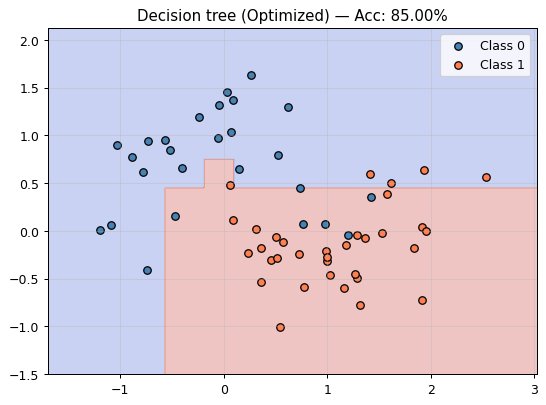

In [6]:
# Optimizamos con regularización estricta para evitar overfitting y ganar accuracy real
tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, criterion='entropy', random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

print(f'Decision tree accuracy (optimized, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points')

plot_decision_boundary(tree, X_test, y_test, f'Decision tree (Optimized) — Acc: {acc_tree:.2%}')

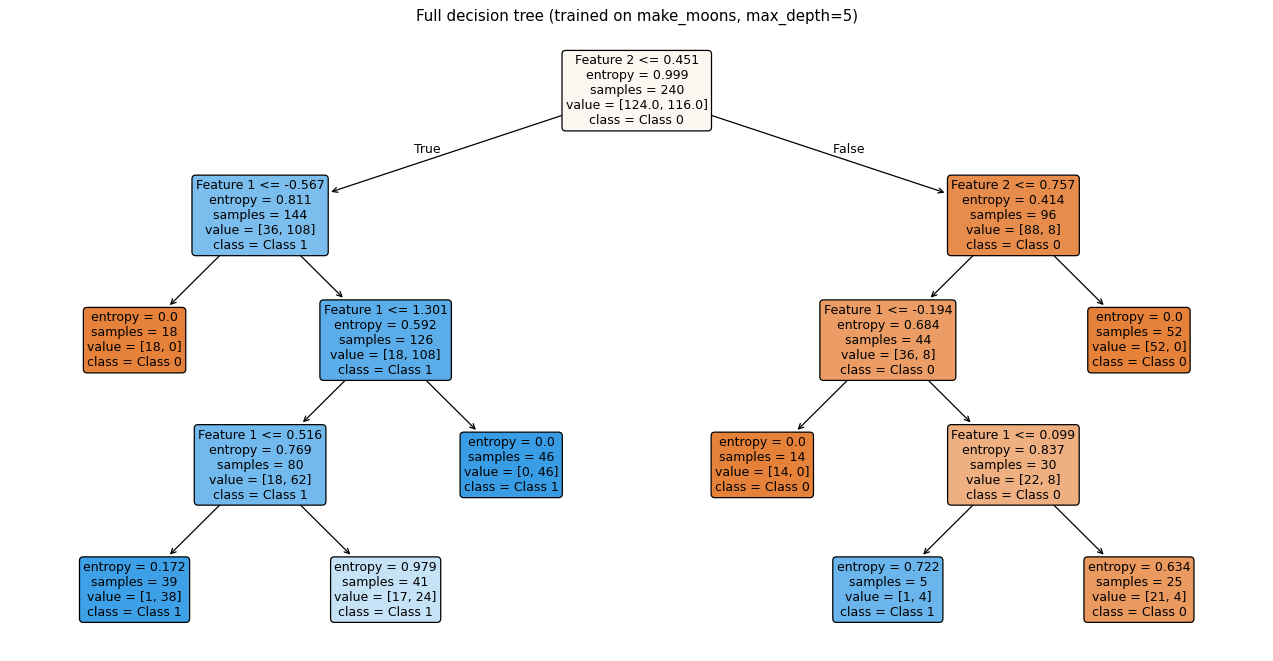

In [7]:
plt.figure(figsize=(18, 9))
plot_tree(
    tree,
    filled=True,
    rounded=True,
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Class 0', 'Class 1'],
    fontsize=10
)
plt.title('Full decision tree (trained on make_moons, max_depth=5)')
plt.show()

Explication 

The figure presents a decision tree model, a classification technique that organizes data through a series of binary decisions. Beginning at the root node, the model evaluates specific conditions and divides the data into branches according to the outcome of each test. This step-by-step process continues until a leaf node is reached, where the final class prediction is assigned. In the diagram, orange nodes indicate Class 0 and blue nodes indicate Class 1. The color intensity reflects the confidence of the prediction: darker shades represent more homogeneous nodes and greater certainty, while lighter shades suggest a higher level of uncertainty.

### Example Dataset: FIFA World Cup Matches

To demonstrate how a Decision Tree classifier works, we use a dataset inspired by FIFA World Cup matches. Each row represents a team's performance in a match, using features such as goals scored, shots on target, and ball possession percentage. The target variable is the match result, which can be classified as Win, Draw, or Loss.

The Decision Tree model learns patterns from these match statistics and generates decision rules that can predict the outcome of future matches.

In [3]:
import pandas as pd

world_cup_data = pd.DataFrame({
    'Team': ['Argentina', 'France', 'Mexico', 'Brazil',
             'Poland', 'Morocco', 'Germany', 'Croatia'],
    'Goals_Scored': [3, 2, 1, 4, 0, 2, 1, 2],
    'Possession': [62, 58, 49, 67, 41, 45, 60, 54],
    'Qualified': ['Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes']
})

world_cup_data

,Team,Goals_Scored,Possession,Qualified
0,Argentina,3,62,Yes
1,France,2,58,Yes
2,Mexico,1,49,No
3,Brazil,4,67,Yes
4,Poland,0,41,No
5,Morocco,2,45,Yes
6,Germany,1,60,No
7,Croatia,2,54,Yes
